# CUSTOMER TRANSACTIONS

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

In [3]:
# reading the data
cus_df = pd.read_csv('./customer_transactions.csv')

# data analyzing

In [4]:
# seeing a sample of the data
cus_df.sample(10)

,id,annual_spend,purchase_frequency,avg_basket_size,days_since_last_purchase,product_category,region
193,194,17623,16,1376,180,Home,South
362,363,47462,35,1264,241,Electronics,North
24,25,2023,5,409,242,Apparel,North
78,79,56726,44,1388,125,Electronics,East
133,134,9544,11,724,59,Beauty,South
17,18,20069,28,689,250,Grocery,NaN
199,200,4240,11,342,242,Apparel,East
453,454,11335,12,881,271,Electronics,South
351,352,4002,10,345,84,Grocery,South
20,21,1947,5,440,276,Apparel,East


In [5]:
cus_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   id                        500 non-null    int64 
 1   annual_spend              500 non-null    int64 
 2   purchase_frequency        500 non-null    int64 
 3   avg_basket_size           500 non-null    int64 
 4   days_since_last_purchase  500 non-null    int64 
 5   product_category          500 non-null    object
 6   region                    484 non-null    object
dtypes: int64(5), object(2)
memory usage: 27.5+ KB


In [6]:
round(cus_df.describe().T,2)

,count,mean,std,min,25%,50%,75%,max
id,500.0,250.50,144.48,1.0,125.75,250.5,375.25,500.0
annual_spend,500.0,19582.74,21828.43,911.0,3258.25,10011.0,33225.50,93182.0
purchase_frequency,500.0,17.96,14.23,1.0,7.00,13.0,25.25,52.0
avg_basket_size,500.0,823.87,648.93,128.0,349.75,628.5,1029.75,3168.0
days_since_last_purchase,500.0,204.81,128.57,0.0,95.50,209.0,284.50,721.0


In [7]:
cus_df.isna().sum() # checking for null values

id                           0
annual_spend                 0
purchase_frequency           0
avg_basket_size              0
days_since_last_purchase     0
product_category             0
region                      16
dtype: int64

In [9]:
# the column id is not needed 
cus_df.drop('id',inplace = True , axis = 1)

* the column region has 16 null values

In [8]:
categorical_cols = cus_df.select_dtypes(include = 'object').columns.tolist()

for cols in categorical_cols:
    unique_value = cus_df[cols].unique()
    print(f"Columns : {cols}")
    print(f"Unique : {unique_value}")
    print("\n")

Columns : product_category
Unique : ['Beauty' 'Apparel' 'Electronics' 'Home' 'Grocery']


Columns : region
Unique : ['North' nan 'South' 'East' 'West' 'International']




* OBSERVATION : see the above values the smart decision would be using label-encoder or one-hot-encoder instead of mapping them

In [17]:
# filling the null values in 'region'

cus_df['region'] = cus_df['region'].fillna(cus_df['region'].mode()[0])
cus_df.region.unique()

array(['North', 'West', 'South', 'East', 'International'], dtype=object)

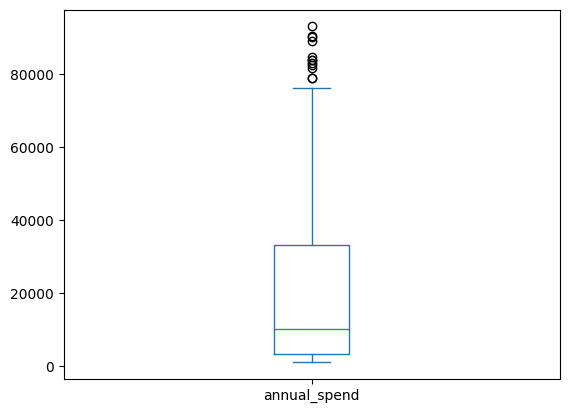

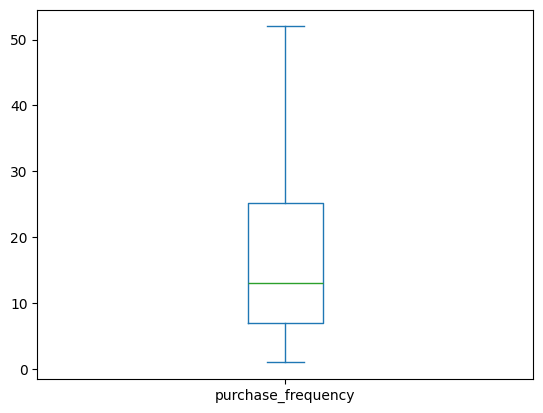

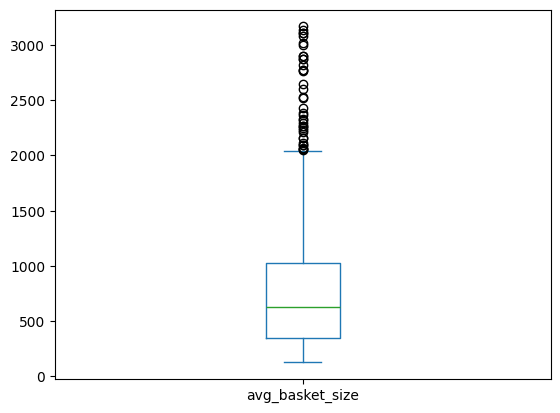

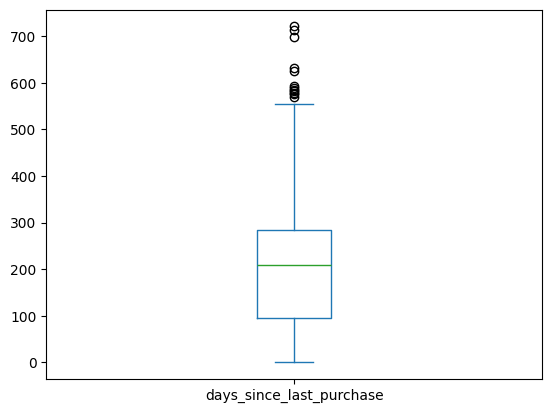

In [16]:
# checking for outliers
numeric_cols = cus_df.select_dtypes(include=np.number).columns.tolist()
def plot(cols) :
    cus_df[[cols]].plot(kind = 'box')

for cols in numeric_cols :
    plot(cols)

In [14]:
# checking for skewed data
numeric_cols = cus_df.select_dtypes(include = np.number).columns.tolist()

for cols in numeric_cols:
    skw = cus_df[cols].skew()
    print(f"Column : {cols}")
    print(f"skew value : {skw}")

Column : annual_spend
skew value : 1.2775782803009799
Column : purchase_frequency
skew value : 1.0413309111669946
Column : avg_basket_size
skew value : 1.6295818361251455
Column : days_since_last_purchase
skew value : 0.7876158038386342


* IT IS MOSTLY RIGHT SKEWED AND DAY_SINCE_LAST_PURCHASE IS AT BORDERLINE (STANDARD SCALER WOULD BE ENOUGH HERE)
* ANNUAL_SPEND AND AVG_BASKET_SIZE NEED TO BE LOG TRANSFORMED 
* MOREOVER WE NEED TO SQUARE ROOT THE PURCHASE_FREQUENCY

In [18]:
# highly skewed
cus_df['avg_basket_size_log'] = np.log10(cus_df['avg_basket_size'])
cus_df['annual_spend_log'] = np.log10(cus_df['annual_spend'])

# midly skewed
cus_df['purchase_frequency_sqrt'] = np.sqrt(cus_df['purchase_frequency'])

In [19]:
cus_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   annual_spend              500 non-null    int64  
 1   purchase_frequency        500 non-null    int64  
 2   avg_basket_size           500 non-null    int64  
 3   days_since_last_purchase  500 non-null    int64  
 4   product_category          500 non-null    object 
 5   region                    500 non-null    object 
 6   avg_basket_size_log       500 non-null    float64
 7   annual_spend_log          500 non-null    float64
 8   purchase_frequency_sqrt   500 non-null    float64
dtypes: float64(3), int64(4), object(2)
memory usage: 35.3+ KB


In [20]:
# copying the data
X = cus_df.copy()

In [21]:
# Scaling the numeric features
numeric_feature = ['avg_basket_size_log','annual_spend_log','purchase_frequency_sqrt','days_since_last_purchase']

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X[numeric_feature])
X[numeric_feature] = scaler.transform(X[numeric_feature])

In [24]:
# encoding the categorical cols
cat_cols = X.select_dtypes(include = 'object').columns.tolist()

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False , handle_unknown='ignore').fit(X[cat_cols])
encoded = list(encoder.get_feature_names_out(cat_cols))
X[encoded] = encoder.transform(X[cat_cols])

# dropping the cat_cols
X.drop(columns = cat_cols, inplace = True)

In [25]:
X.columns

Index(['annual_spend', 'purchase_frequency', 'avg_basket_size',
       'days_since_last_purchase', 'avg_basket_size_log', 'annual_spend_log',
       'purchase_frequency_sqrt', 'product_category_Apparel',
       'product_category_Beauty', 'product_category_Electronics',
       'product_category_Grocery', 'product_category_Home', 'region_East',
       'region_International', 'region_North', 'region_South', 'region_West'],
      dtype='object')

In [28]:
X_train = X[numeric_feature + encoded]
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   avg_basket_size_log           500 non-null    float64
 1   annual_spend_log              500 non-null    float64
 2   purchase_frequency_sqrt       500 non-null    float64
 3   days_since_last_purchase      500 non-null    float64
 4   product_category_Apparel      500 non-null    float64
 5   product_category_Beauty       500 non-null    float64
 6   product_category_Electronics  500 non-null    float64
 7   product_category_Grocery      500 non-null    float64
 8   product_category_Home         500 non-null    float64
 9   region_East                   500 non-null    float64
 10  region_International          500 non-null    float64
 11  region_North                  500 non-null    float64
 12  region_South                  500 non-null    float64
 13  regio

## MODEL TRAINING


Text(0, 0.5, 'Inertia')

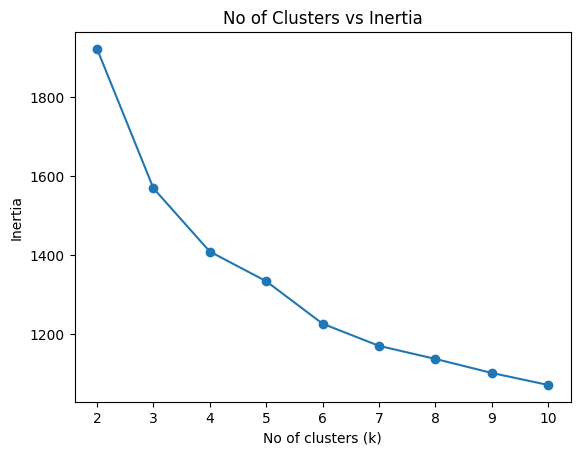

In [29]:
# ELBOW METHOD
from sklearn.cluster import KMeans

options = range(2,11)
inertia = []

for k in options :
    model = KMeans(n_clusters=k, random_state=42).fit(X_train)
    inertia.append(model.inertia_)

plt.title("No of Clusters vs Inertia")
plt.plot(options,inertia,'-o')
plt.xlabel("No of clusters (k)")
plt.ylabel("Inertia")

* the elbow is point towards 4 (my guess)

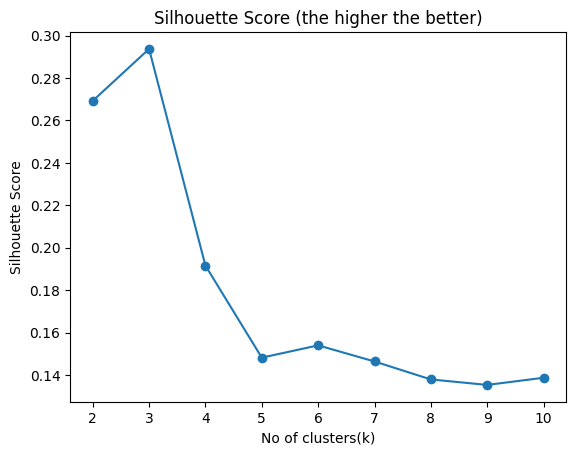

In [32]:
# confirming it with silhouette score
from sklearn.metrics import silhouette_score

sil_score = []
options = range(2,11)

for k in options:
    kmeans = KMeans(n_clusters=k,random_state=42)
    labels = kmeans.fit_predict(X_train)
    sil_score.append(silhouette_score(X_train,labels))

plt.title('Silhouette Score (the higher the better)')
plt.plot(options,sil_score,marker = 'o')
plt.ylabel('Silhouette Score')
plt.xlabel('No of clusters(k)')
plt.show()

Silhouette score confirms it to be 3 not 4

In [ ]:
# KMEANS
kmeans = KMeans(n_clusters=3,random_state=42)
pred = kmeans.fit_predict(X_train)

silhouette = silhouette_score(X_train,pred)
print(silhouette)

0.2936883322460662


In [36]:
# MINI-BATCH KMEANS

from sklearn.cluster import MiniBatchKMeans

mkmeans = MiniBatchKMeans(n_clusters=3, random_state = 42)
pred = mkmeans.fit_predict(X_train)

silhouette = silhouette_score(X_train,pred)
print(silhouette)

0.29387523903931195


In [51]:
from sklearn.decomposition import PCA
def train_model(model,X_train,name):
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_train)

    preds = model.fit_predict(X_pca)
    silhouette = silhouette_score(X_pca,preds)
    X_with_labels = X_train.copy()
    X_with_labels['cluster'] = preds

    cluster_summary = X_with_labels.groupby('cluster').mean()
    print(cluster_summary)
    print(f"silhouette score : {silhouette}")
    plt.figure(figsize=(8,5))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=preds, cmap='viridis')

    centers_pca = model.cluster_centers_
    plt.scatter(centers_pca[:, 0], centers_pca[:, 1], 
                color='red', marker='X', s=200)

    plt.title(f"{name} Clusters (PCA)")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.show()

         avg_basket_size_log  annual_spend_log  purchase_frequency_sqrt  \
cluster                                                                   
0                  -0.778888         -0.891358                -0.641834   
1                   1.974312          1.561379                -1.506604   
2                   0.603115          0.769111                 0.851214   

         days_since_last_purchase  product_category_Apparel  \
cluster                                                       
0                       -0.100406                  0.192623   
1                        2.500122                  0.230769   
2                       -0.176105                  0.243478   

         product_category_Beauty  product_category_Electronics  \
cluster                                                          
0                       0.286885                      0.159836   
1                       0.153846                      0.269231   
2                       0.186957            

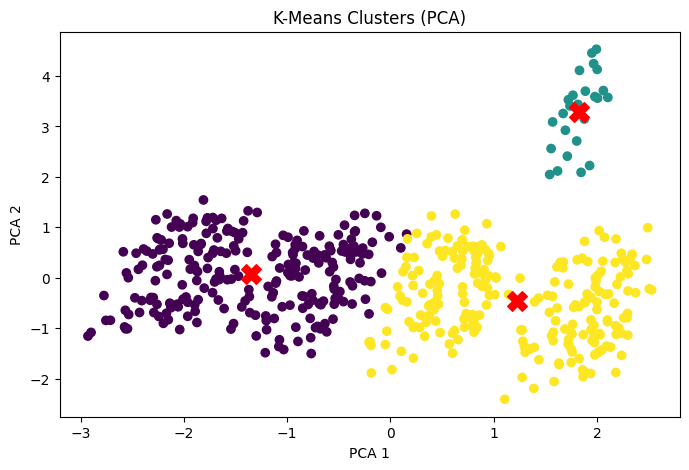

In [52]:
train_model(KMeans(random_state=42,n_clusters=3),X_train,'K-Means')

## Cluster 0 → “Low income, low spenders”
## Cluster 1 → “Average customers”
## Cluster 2 → “High-value customers”

         avg_basket_size_log  annual_spend_log  purchase_frequency_sqrt  \
cluster                                                                   
0                   1.974312          1.561379                -1.506604   
1                  -0.788947         -0.903194                -0.648409   
2                   0.595726          0.759974                 0.838791   

         days_since_last_purchase  product_category_Apparel  \
cluster                                                       
0                        2.500122                  0.230769   
1                       -0.104485                  0.190871   
2                       -0.170911                  0.244635   

         product_category_Beauty  product_category_Electronics  \
cluster                                                          
0                       0.153846                      0.269231   
1                       0.282158                      0.161826   
2                       0.193133            

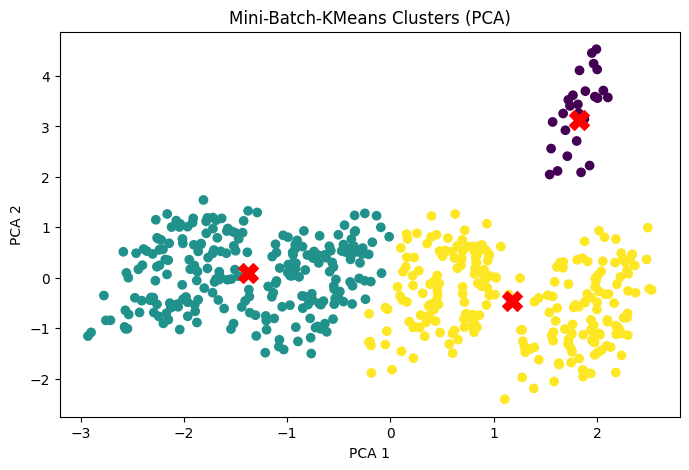

In [53]:
train_model(MiniBatchKMeans(random_state= 42, n_clusters=3),X_train,'Mini-Batch-KMeans')